# Reporte Visual — Pipeline Predictivo de Dominios Ferroelectricos

Lee los resultados ya generados por los scripts de inferencia y los
training logs. **No corre inferencia, no carga modelos, no guarda nada**:
todo se muestra en linea.

Orden previo obligatorio: `inferencia_regresion_C2` -> `inferencia_regresion_C3`
-> `inferencia_segmentacion`.

Secciones frame a frame: un bloque por modo (independiente y autoregresiva)
mas los frames sin ground truth.


In [16]:
import os, csv, math, glob
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import torch
from IPython.display import display
from PIL import Image

matplotlib.rcParams['figure.dpi'] = 100
print("Imports ok")

Imports ok


## 1. Configuración


In [17]:
BASE_DIR = Path(r'C:\Users\migue\Desktop\modelo_predictivo')
DATA_DIR = BASE_DIR / 'data'
RES_DIR  = BASE_DIR / 'resultados'

# Training logs
SEG_LOG    = RES_DIR / 'modelo_segmentacion'  / 'training_log.csv'
RC2_LOG    = RES_DIR / 'modelo_regresion_C2'  / 'training_log.csv'
RC3_LOG    = RES_DIR / 'modelo_regresion_c3'  / 'training_log.csv'

# Checkpoints (solo para leer epoch y metrica, sin cargar modelo)
SEG_CKPT   = RES_DIR / 'modelo_segmentacion'  / 'checkpoints' / 'best_model.pth'
RC2_CKPT   = RES_DIR / 'modelo_regresion_C2'  / 'checkpoints' / 'best_model.pth'
RC3_CKPT   = RES_DIR / 'modelo_regresion_c3'  / 'checkpoints' / 'best_model.pth'

# Metricas de inferencia
SEG_MET_I  = RES_DIR / 'modelo_segmentacion'  / 'predicciones' / 'metricas_independiente.csv'
SEG_MET_A  = RES_DIR / 'modelo_segmentacion'  / 'predicciones' / 'metricas_autoregresiva.csv'
RC2_MET_I  = RES_DIR / 'modelo_regresion_C2'  / 'predicciones' / 'metricas_independiente.csv'
RC2_MET_A  = RES_DIR / 'modelo_regresion_C2'  / 'predicciones' / 'metricas_autoregresiva.csv'
RC3_MET_I  = RES_DIR / 'modelo_regresion_c3'  / 'predicciones' / 'metricas_independiente.csv'
RC3_MET_A  = RES_DIR / 'modelo_regresion_c3'  / 'predicciones' / 'metricas_autoregresiva.csv'

# Carpetas NPY de predicciones
SEG_NPY    = RES_DIR / 'modelo_segmentacion'  / 'predicciones' / 'npy'
RC2_NPY    = RES_DIR / 'modelo_regresion_C2'  / 'predicciones' / 'npy'
RC3_NPY    = RES_DIR / 'modelo_regresion_c3'  / 'predicciones' / 'npy'

# Modos a visualizar. Los frames sin ground truth se muestran aparte,
# porque son los mismos sin importar el modo.
MODOS = ['independiente', 'autoregresiva']

# Colores
BLUE='#378ADD'; ORANGE='#D85A30'; GREEN='#1D9E75'
PURPLE='#534AB7'; TEAL='#0F6E56'; GRAY='#888780'

print("Configuracion cargada.")
print(f"  Modos a visualizar: {MODOS} + sin ground truth")


Configuracion cargada.
  Modos a visualizar: ['independiente', 'autoregresiva'] + sin ground truth


## 2. Funciones auxiliares


In [18]:
def read_csv(path):
    if not Path(path).exists():
        print(f"  AVISO: no encontrado: {path}"); return []
    rows = []
    with open(str(path), 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            parsed = {}
            for k, v in row.items():
                try: parsed[k] = float(v)
                except ValueError: parsed[k] = v
            rows.append(parsed)
    return rows

def read_ckpt_info(path):
    if not Path(path).exists():
        print(f"  AVISO: checkpoint no encontrado: {path}"); return {}
    ckpt = torch.load(str(path), map_location='cpu')
    return {k: v for k, v in ckpt.items() if k != 'model_state'}

def load_npy(path, normalize=True):
    arr = np.load(str(path)).astype(np.float32)
    if normalize:
        mn, mx = arr.min(), arr.max()
        if mx - mn > 1e-8: arr = (arr - mn) / (mx - mn)
    return arr

def avg(lst, key):
    vals = [r[key] for r in lst if r.get(key) not in (None,'','None')]
    return round(sum(vals)/len(vals), 4) if vals else None

def avg_str(lst, key, fmt='.4f'):
    v = avg(lst, key)
    return f'{v:{fmt}}' if v is not None else 'N/A'


def cargar_inputs_frame(frame_num, modo, paso=0):
    """Reconstruye los inputs que el script de inferencia alimento al modelo.

    independiente -> los 3 canales reales siempre.
    autoregresiva -> paso 0 real; pasos 1+ toman '_auto_pred' de C2 y C3
                     y el '_auto_diff' de C2.
    sin_gt        -> paso 0 real; pasos 1+ toman '_sin_gt_pred' y
                     '_sin_gt_diff_pred'.

    El diff se guarda bajo el stem del frame TARGET aunque su contenido
    corresponda al frame de input, por eso su clave es frame_num.
    """
    inp = frame_num - 1

    def _lnpy(path):
        a = np.load(str(path)).astype(np.float32)
        mn, mx = a.min(), a.max()
        if mx-mn > 1e-8: a = (a-mn)/(mx-mn)
        return a

    def _real(folder, pos):
        lst = sorted(Path(folder).glob('*.npy'))
        return _lnpy(lst[pos-1]) if 0 < pos <= len(lst) else None

    def _cargar(npy_dir, sub, stem):
        if npy_dir is None: return None
        c = list(Path(npy_dir/sub).glob(stem + '.npy'))
        return _lnpy(c[0]) if c else None

    if modo == 'autoregresiva' and paso > 0:
        suf_pred, suf_diff = 'auto_pred', 'auto_diff'
    elif modo == 'sin_gt' and paso > 0:
        suf_pred, suf_diff = 'sin_gt_pred', 'sin_gt_diff_pred'
    else:
        suf_pred, suf_diff = None, None

    # C2 input
    c2_input = _cargar(RC2_NPY, 'pred', f'frame_{inp:03d}_{suf_pred}') if suf_pred else None
    if c2_input is not None:
        c2_fuente = f'C2 predicho frame {inp}'
    else:
        c2_input  = _real(DATA_DIR/'canal_2', inp)
        c2_fuente = f'C2 real frame {inp}'

    # C2 diff — el del frame N esta en la posicion N-1
    c2_diff = _cargar(RC2_NPY, 'diff_pred', f'frame_{frame_num:03d}_{suf_diff}') if suf_diff else None
    if c2_diff is not None:
        diff_fuente = 'encadenado'
    else:
        n_diff      = len(sorted((DATA_DIR/'diff').glob('*.npy')))
        c2_diff     = _real(DATA_DIR/'diff', min(inp-1, n_diff))
        diff_fuente = 'real'

    # C3 input — siempre fase continua, nunca la mascara binaria
    c3_input = _cargar(RC3_NPY, 'pred', f'frame_{inp:03d}_{suf_pred}') if suf_pred else None
    if c3_input is not None:
        c3_fuente = f'C3 predicho frame {inp}'
    else:
        n_c3      = len(sorted((DATA_DIR/'canal_3').glob('*.npy')))
        c3_input  = _real(DATA_DIR/'canal_3', min(inp, n_c3))
        c3_fuente = f'C3 real frame {inp}'

    return c2_input, c2_diff, c3_input, c2_fuente, c3_fuente, diff_fuente


def cargar_frames_modo(modo, incluir_gt=True, incluir_sin_gt=True):
    """Carga los NPY de los 3 modelos. Empareja por NUMERO DE FRAME, no por
    indice de lista: si una carpeta tiene un archivo de mas, emparejar por
    posicion desalinearia los modelos en silencio."""
    sufijo = 'indep' if modo == 'independiente' else 'auto'
    def _ls(folder, pat): return sorted(Path(folder).glob(pat)) if Path(folder).exists() else []
    def _fn(p):
        try: return int(p.stem.split('_')[1])
        except: return 0
    def _by(lst): return {_fn(p): p for p in lst}
    def _l(p): return load_npy(p, normalize=True) if p else None
    def _le(p): return load_npy(p, normalize=False) if p else None

    ps = _by(_ls(SEG_NPY/'pred', f'*_{sufijo}_pred.npy'))
    rs = _by(_ls(SEG_NPY/'pred_con_gt', f'*_{sufijo}_pred_con_gt.npy'))
    es = _by(_ls(SEG_NPY/'error', f'*_{sufijo}_error.npy'))
    p2 = _by(_ls(RC2_NPY/'pred', f'*_{sufijo}_pred.npy'))
    r2 = _by(_ls(RC2_NPY/'pred_con_gt', f'*_{sufijo}_pred_con_gt.npy'))
    e2 = _by(_ls(RC2_NPY/'error', f'*_{sufijo}_error.npy'))
    p3 = _by(_ls(RC3_NPY/'pred', f'*_{sufijo}_pred.npy'))
    r3 = _by(_ls(RC3_NPY/'pred_con_gt', f'*_{sufijo}_pred_con_gt.npy'))
    e3 = _by(_ls(RC3_NPY/'error', f'*_{sufijo}_error.npy'))

    frames = {}
    comunes = sorted(set(ps) & set(p2) & set(p3)) if incluir_gt else []
    if incluir_gt:
        faltan = (set(ps) | set(p2) | set(p3)) - set(comunes)
        if faltan: print(f"  AVISO: frames en unos modelos y no en otros: {sorted(faltan)}")

    for orden, fn in enumerate(comunes):
        frames[fn] = {'frame': fn, 'modo': modo, 'has_gt': True, 'paso': orden,
                      'seg_pred': _l(ps.get(fn)), 'seg_real': _l(rs.get(fn)), 'seg_error': _le(es.get(fn)),
                      'rc2_pred': _l(p2.get(fn)), 'rc2_real': _l(r2.get(fn)), 'rc2_error': _le(e2.get(fn)),
                      'rc3_pred': _l(p3.get(fn)), 'rc3_real': _l(r3.get(fn)), 'rc3_error': _le(e3.get(fn))}

    if incluir_sin_gt:
        ss = _by(_ls(SEG_NPY/'pred', '*_sin_gt_pred.npy'))
        s2 = _by(_ls(RC2_NPY/'pred', '*_sin_gt_pred.npy'))
        s3 = _by(_ls(RC3_NPY/'pred', '*_sin_gt_pred.npy'))
        for orden, fn in enumerate(sorted(set(ss) & set(s2) & set(s3))):
            def _prev(npy_dir, fp):
                # Solo la cadena sin GT: en el paso 0 el input fue el frame
                # REAL, no una prediccion, y mostrarla seria enganoso.
                c = list(Path(npy_dir/'pred').glob(f'frame_{fp:03d}_sin_gt_pred.npy'))
                return _l(c[0]) if c else None
            def _err(npy_dir, f):
                c = list(Path(npy_dir/'error').glob(f'frame_{f:03d}_sin_gt_error.npy'))
                return _l(c[0]) if c else None

            sg, sp = _l(ss.get(fn)), _prev(SEG_NPY, fn-1)
            v2, q2 = _l(s2.get(fn)), _prev(RC2_NPY, fn-1)
            v3, q3 = _l(s3.get(fn)), _prev(RC3_NPY, fn-1)

            # Error desde disco; si no existe, calcularlo en memoria.
            # Comparar contra None explicitamente: 'a or b' evalua el valor
            # de verdad de un array de numpy y lanza ValueError.
            def _o_calc(desde_disco, a, b):
                if desde_disco is not None:
                    return desde_disco
                if a is not None and b is not None:
                    return np.abs(a - b)
                return None

            eg = _o_calc(_err(SEG_NPY, fn), sg, sp)
            f2 = _o_calc(_err(RC2_NPY, fn), v2, q2)
            f3 = _o_calc(_err(RC3_NPY, fn), v3, q3)

            frames[fn] = {'frame': fn, 'modo': 'sin_gt', 'has_gt': False, 'paso': orden,
                          'seg_pred': sg, 'seg_real': sp, 'seg_error': eg,
                          'rc2_pred': v2, 'rc2_real': q2, 'rc2_error': f2,
                          'rc3_pred': v3, 'rc3_real': q3, 'rc3_error': f3}

    result = sorted(frames.values(), key=lambda x: x['frame'])
    print(f"  {modo:<15}: {len(result)} frames")
    return result


def imshow_cb(ax, data, cmap, title, vmin=0, vmax=1):
    if data is None:
        ax.set_facecolor('#EEEEEE')
        ax.text(0.5,0.5,'no disponible',ha='center',va='center',
                fontsize=7,color='gray_r',transform=ax.transAxes)
    else:
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=8); ax.axis('off')

print("Funciones cargadas.")


Funciones cargadas.


## 3. Cargar datos desde disco


In [19]:
print("Leyendo training logs...")
seg_log = read_csv(SEG_LOG)
rc2_log = read_csv(RC2_LOG)
rc3_log = read_csv(RC3_LOG)
print(f"  Seg: {len(seg_log)} epochs | C2: {len(rc2_log)} epochs | C3: {len(rc3_log)} epochs")

print("\nLeyendo checkpoints (solo info, sin cargar modelo)...")
seg_ckpt = read_ckpt_info(SEG_CKPT)
rc2_ckpt = read_ckpt_info(RC2_CKPT)
rc3_ckpt = read_ckpt_info(RC3_CKPT)
for nom, ck, k in [('Seg', seg_ckpt, 'val_iou'),
                   ('C2 ', rc2_ckpt, 'val_ssim'),
                   ('C3 ', rc3_ckpt, 'val_ssim')]:
    v = ck.get(k)
    val = f"{v:.4f}" if isinstance(v, float) else '?'
    print(f"  {nom}  epoch={ck.get('epoch','?')}  {k}={val}")

print("\nLeyendo metricas de inferencia...")
seg_i = read_csv(SEG_MET_I); seg_a = read_csv(SEG_MET_A)
rc2_i = read_csv(RC2_MET_I); rc2_a = read_csv(RC2_MET_A)
rc3_i = read_csv(RC3_MET_I); rc3_a = read_csv(RC3_MET_A)
print(f"  Seg  indep={len(seg_i)} | auto={len(seg_a)}")
print(f"  C2   indep={len(rc2_i)} | auto={len(rc2_a)}")
print(f"  C3   indep={len(rc3_i)} | auto={len(rc3_a)}")

# Una tanda por modo (solo frames con GT) + los frames sin GT aparte,
# que son identicos en ambos modos y se cargan una sola vez.
print("\nCargando arrays NPY...")
frames_por_modo = {}
for _m in MODOS:
    _fr = cargar_frames_modo(_m, incluir_gt=True, incluir_sin_gt=False)
    if _fr: frames_por_modo[_m] = _fr
frames_sgt = cargar_frames_modo('sin_gt', incluir_gt=False, incluir_sin_gt=True)


Leyendo training logs...
  Seg: 100 epochs | C2: 100 epochs | C3: 100 epochs

Leyendo checkpoints (solo info, sin cargar modelo)...
  Seg  epoch=73  val_iou=0.8276
  C2   epoch=100  val_ssim=0.7714
  C3   epoch=84  val_ssim=0.7747

Leyendo metricas de inferencia...
  Seg  indep=5 | auto=5
  C2   indep=5 | auto=5
  C3   indep=5 | auto=5

Cargando arrays NPY...
  independiente  : 5 frames
  autoregresiva  : 5 frames
  sin_gt         : 5 frames


## 4. Curvas de entrenamiento


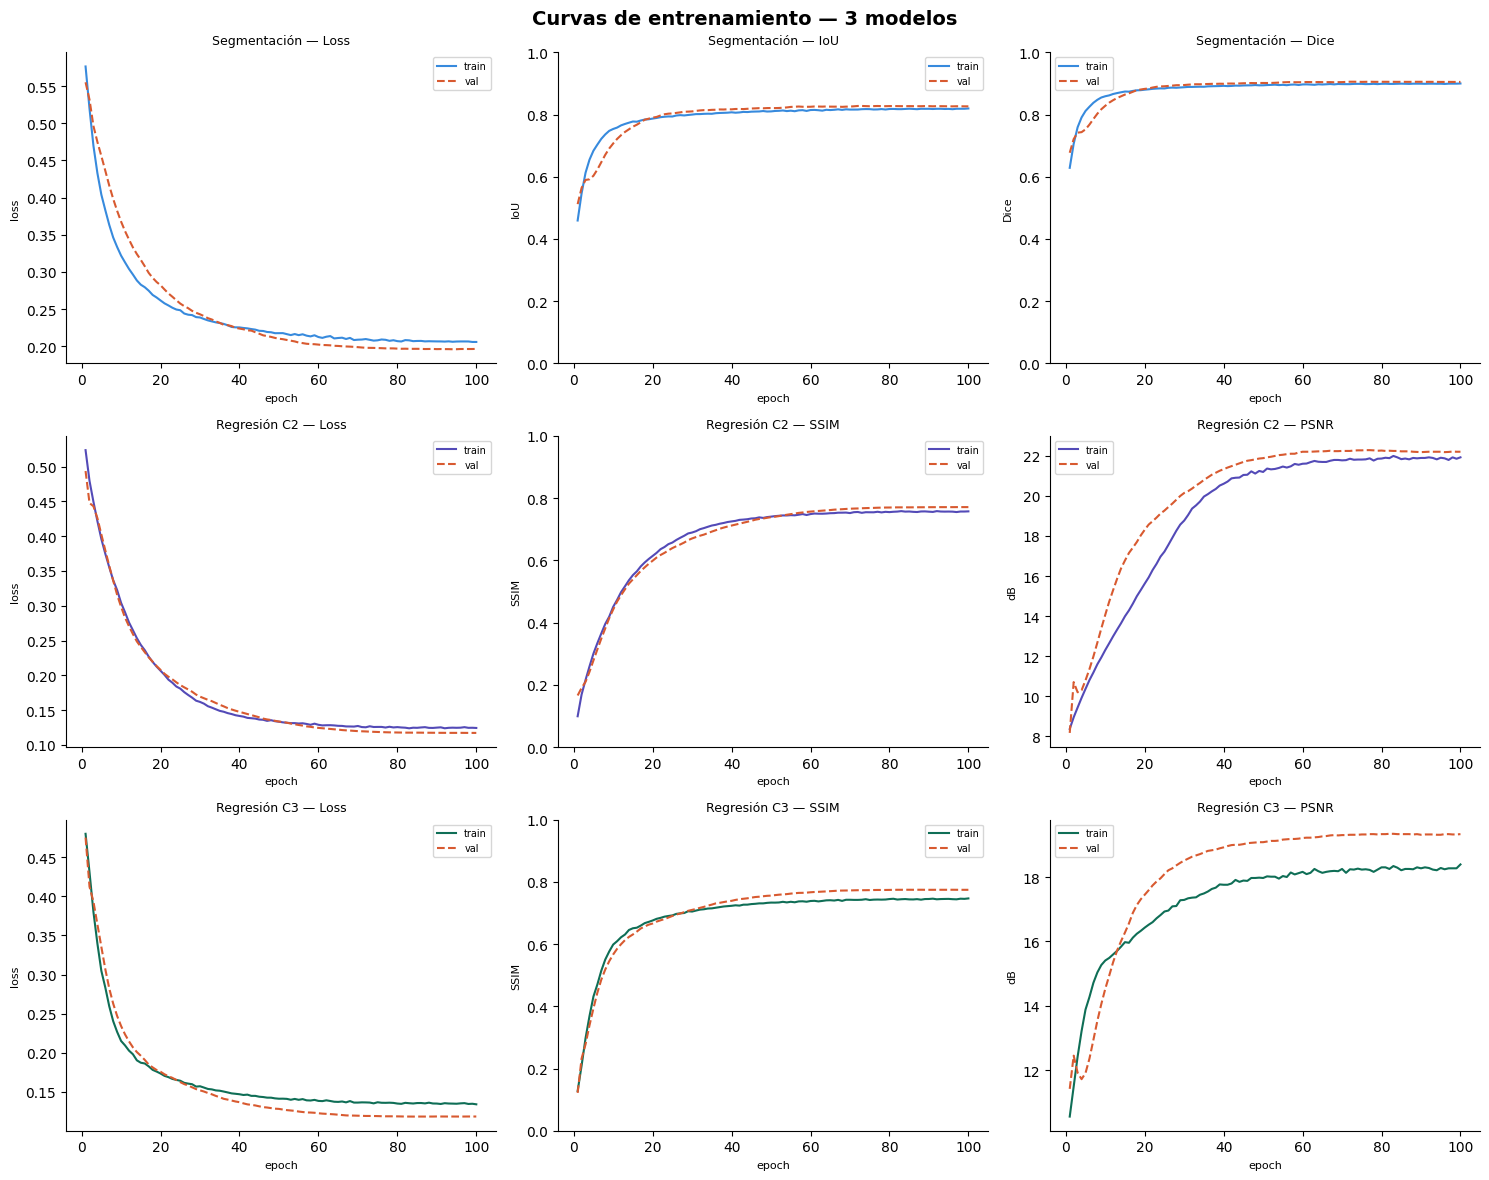

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Curvas de entrenamiento — 3 modelos', fontsize=14, fontweight='bold', y=0.98)

for row_i, (log, color, label, metrics) in enumerate([
    (seg_log, BLUE,   'Segmentación',
     [('train_loss','val_loss','Loss','loss',None),
      ('train_iou','val_iou','IoU','IoU',(0,1)),
      ('train_dice','val_dice','Dice','Dice',(0,1))]),
    (rc2_log, PURPLE, 'Regresión C2',
     [('train_loss','val_loss','Loss','loss',None),
      ('train_ssim','val_ssim','SSIM','SSIM',(0,1)),
      ('train_psnr','val_psnr','PSNR','dB',None)]),
    (rc3_log, TEAL,   'Regresión C3',
     [('train_loss','val_loss','Loss','loss',None),
      ('train_ssim','val_ssim','SSIM','SSIM',(0,1)),
      ('train_psnr','val_psnr','PSNR','dB',None)]),
]):
    if not log: continue
    epochs = [r['epoch'] for r in log]
    for col_i, (tk, vk, title, ylabel, ylim) in enumerate(metrics):
        ax = axes[row_i, col_i]
        ax.plot(epochs, [r.get(tk,0) for r in log], color=color,  lw=1.5, label='train')
        ax.plot(epochs, [r.get(vk,0) for r in log], color=ORANGE, lw=1.5, ls='--', label='val')
        ax.set_title(f'{label} — {title}', fontsize=9)
        ax.set_xlabel('epoch', fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Métricas de inferencia


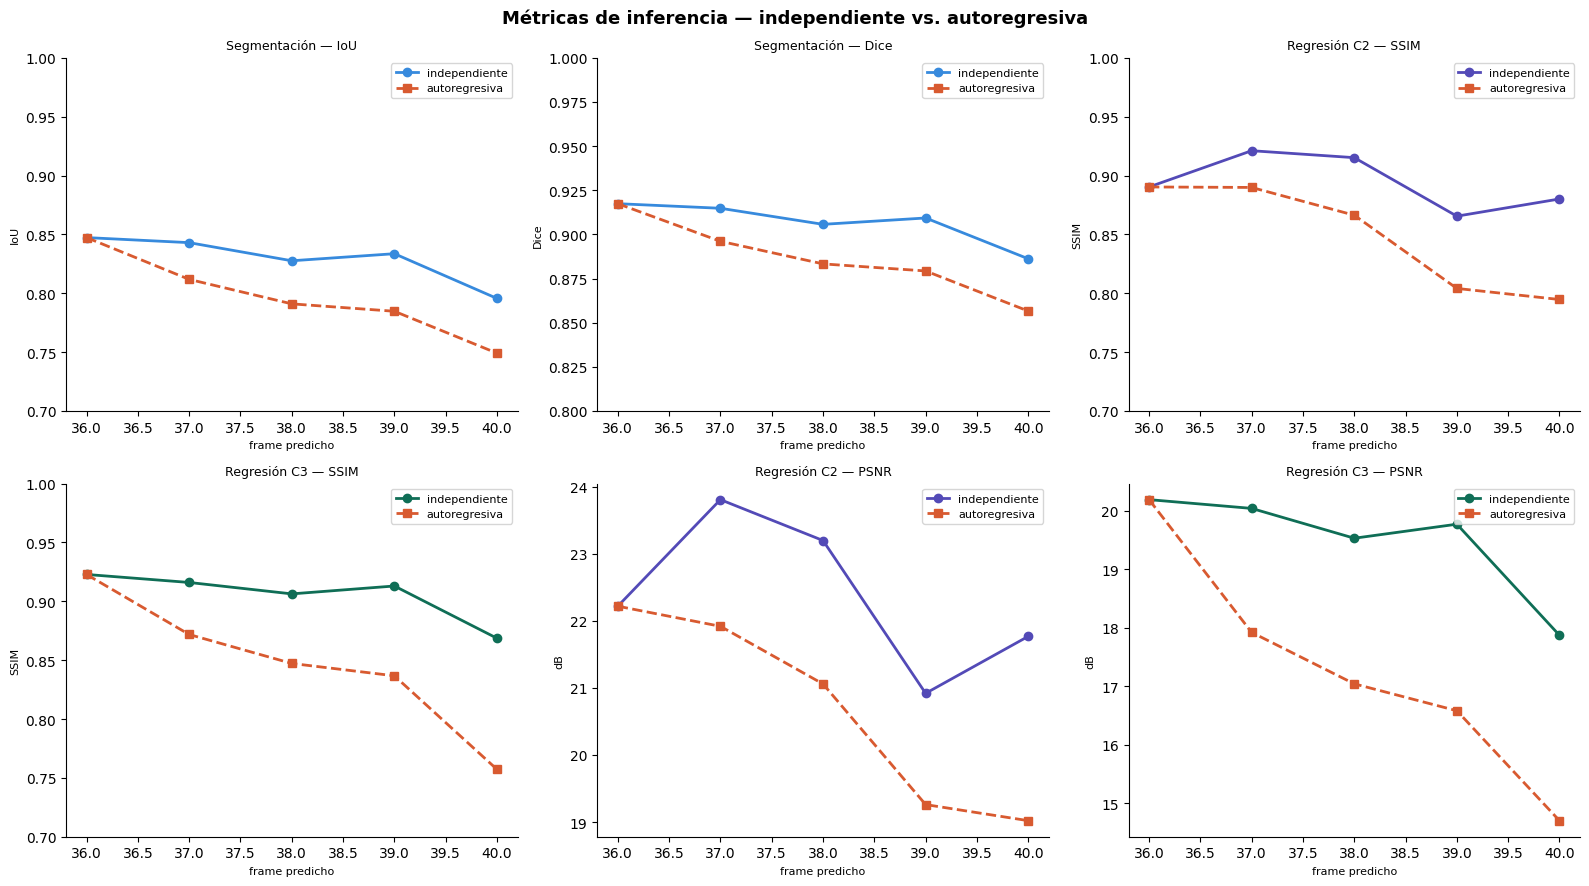

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Métricas de inferencia — independiente vs. autoregresiva',
             fontsize=13, fontweight='bold', y=0.98)

def frames_from(lst): return [int(r['pos_out']) for r in lst]
def vals_from(lst, k): return [r.get(k) for r in lst]

configs = [
    (axes[0,0], seg_i, seg_a, 'iou',  BLUE,   'Segmentación — IoU',  'IoU',  (0.7,1.0)),
    (axes[0,1], seg_i, seg_a, 'dice', BLUE,   'Segmentación — Dice', 'Dice', (0.8,1.0)),
    (axes[0,2], rc2_i, rc2_a, 'ssim', PURPLE, 'Regresión C2 — SSIM', 'SSIM', (0.7,1.0)),
    (axes[1,0], rc3_i, rc3_a, 'ssim', TEAL,   'Regresión C3 — SSIM', 'SSIM', (0.7,1.0)),
    (axes[1,1], rc2_i, rc2_a, 'psnr', PURPLE, 'Regresión C2 — PSNR', 'dB',   None),
    (axes[1,2], rc3_i, rc3_a, 'psnr', TEAL,   'Regresión C3 — PSNR', 'dB',   None),
]
for ax, li, la, key, color, title, ylabel, ylim in configs:
    if li: ax.plot(frames_from(li), vals_from(li,key), 'o-',  color=color,  lw=2, ms=6, label='independiente')
    if la: ax.plot(frames_from(la), vals_from(la,key), 's--', color=ORANGE, lw=2, ms=6, label='autoregresiva')
    ax.set_title(title, fontsize=9); ax.set_xlabel('frame predicho', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Visualización frame a frame


  MODO INDEPENDIENTE


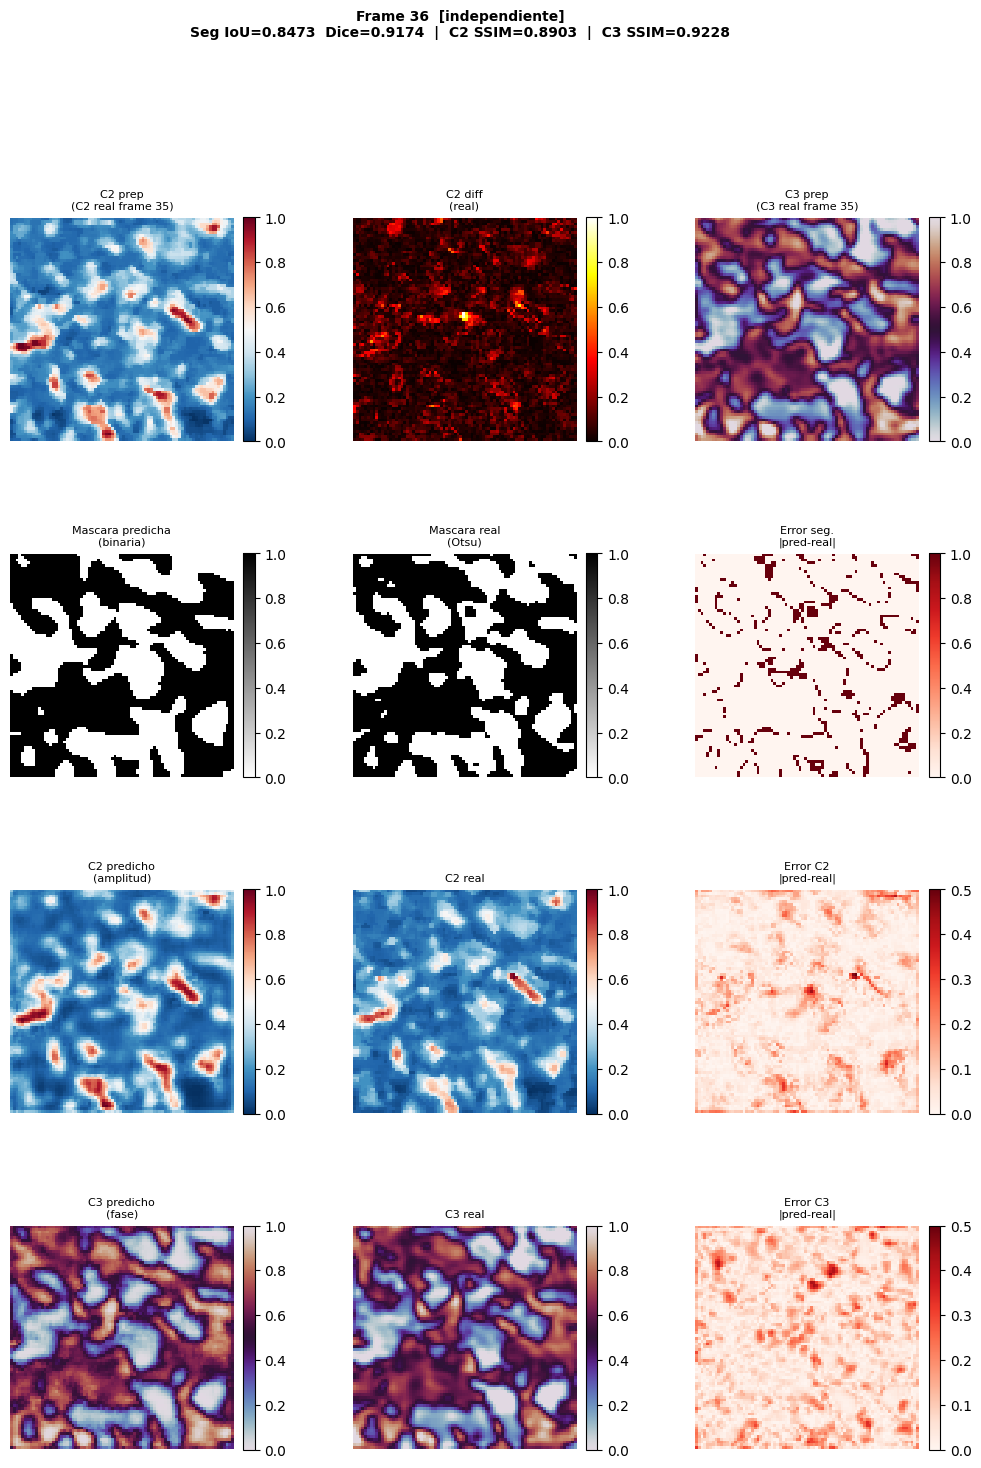

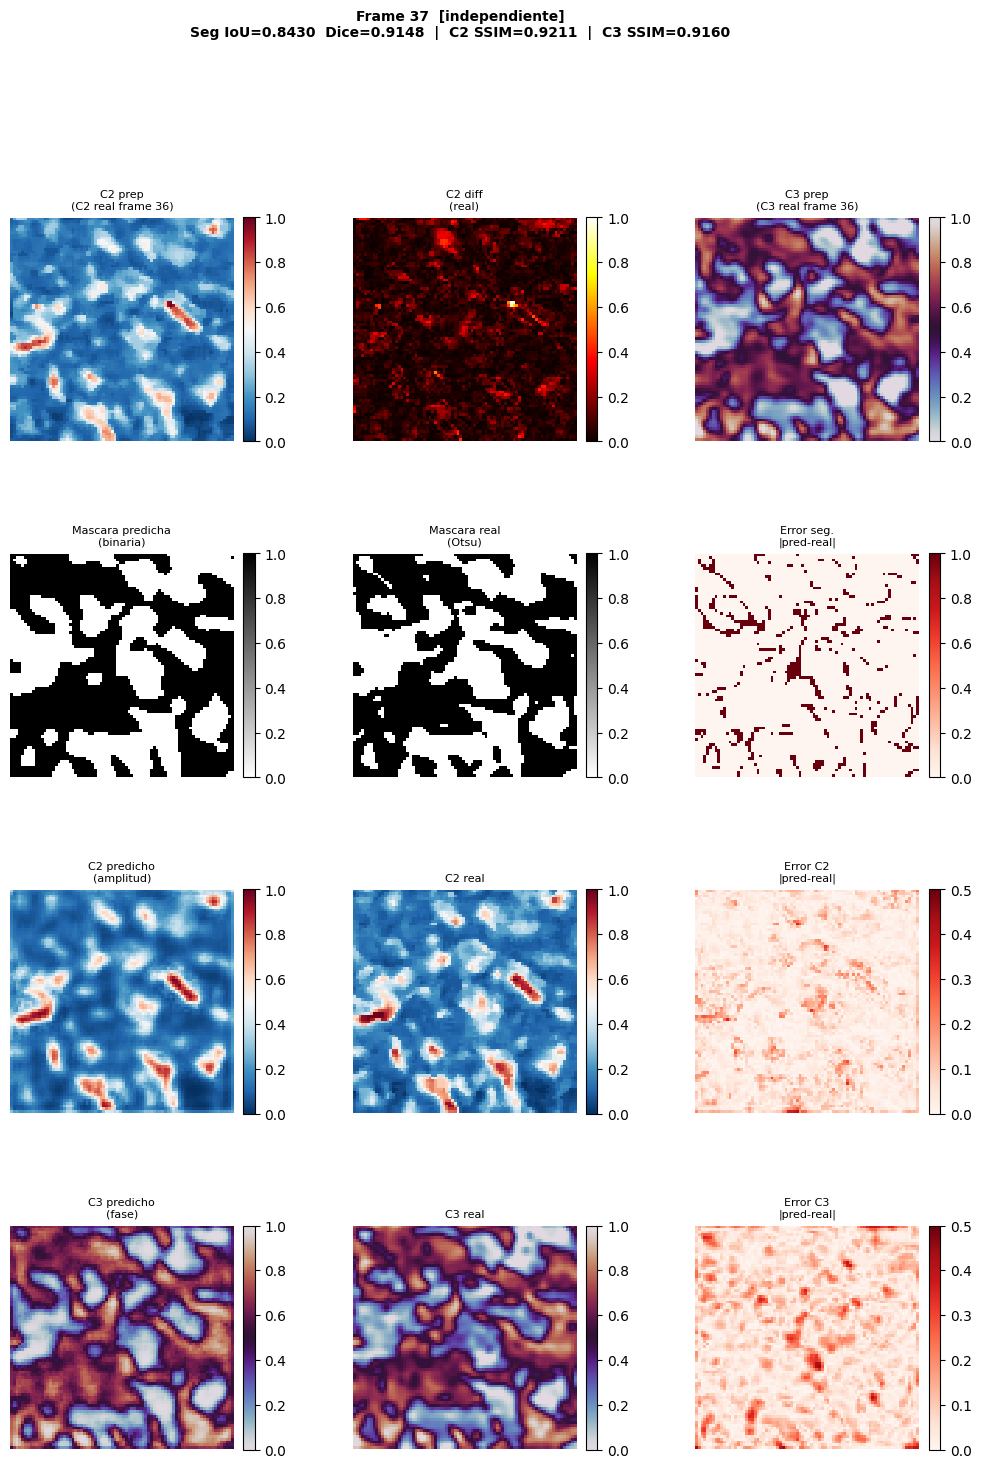

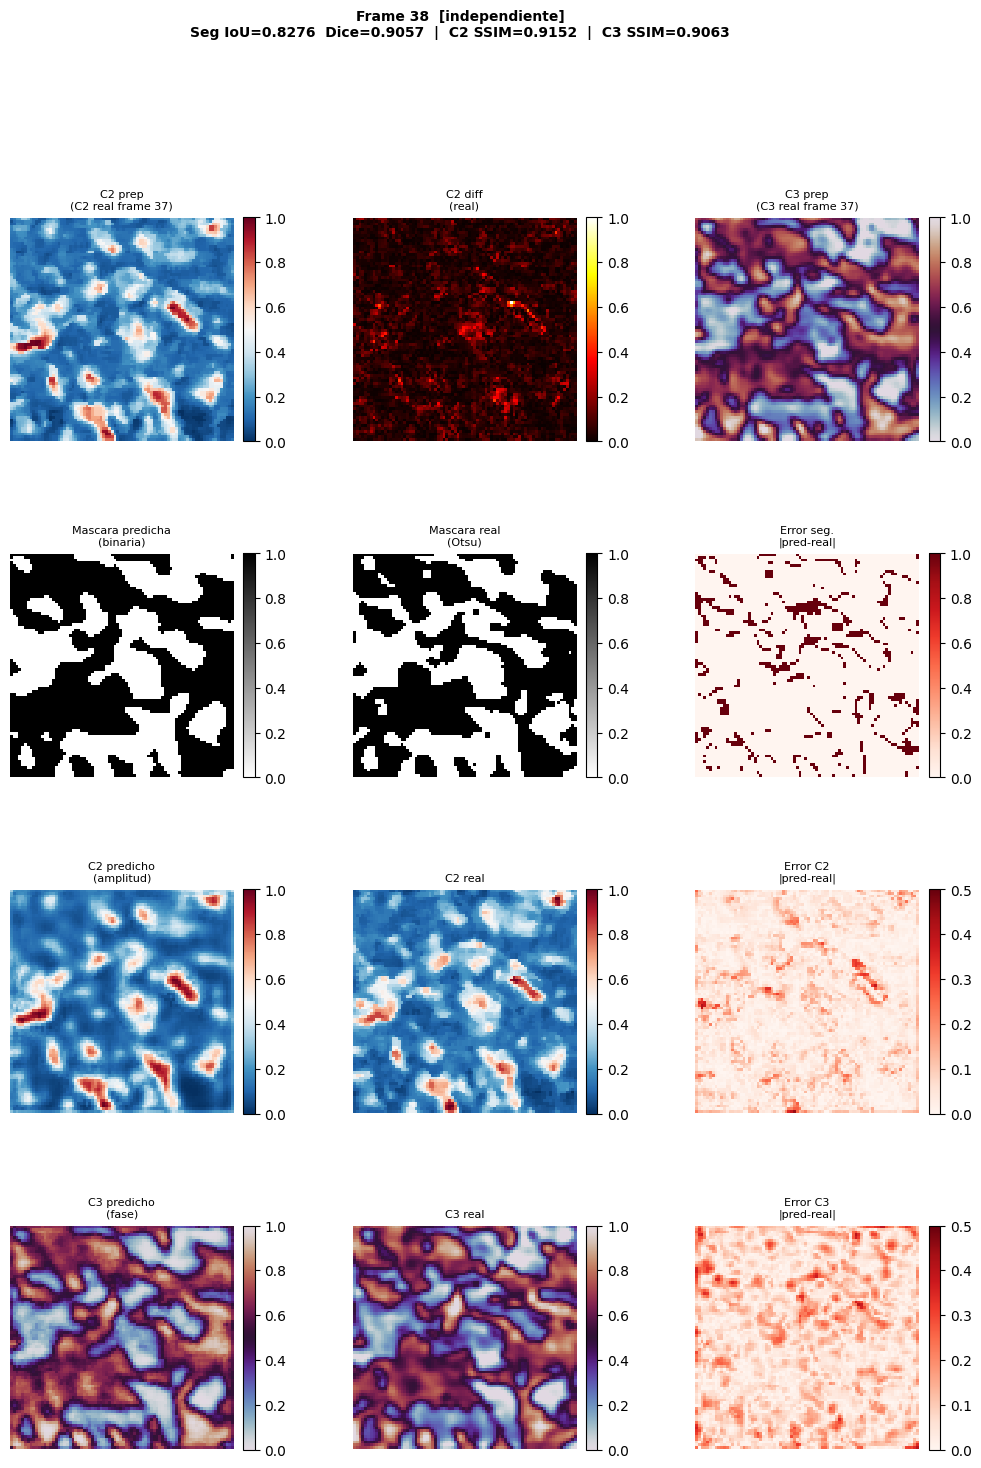

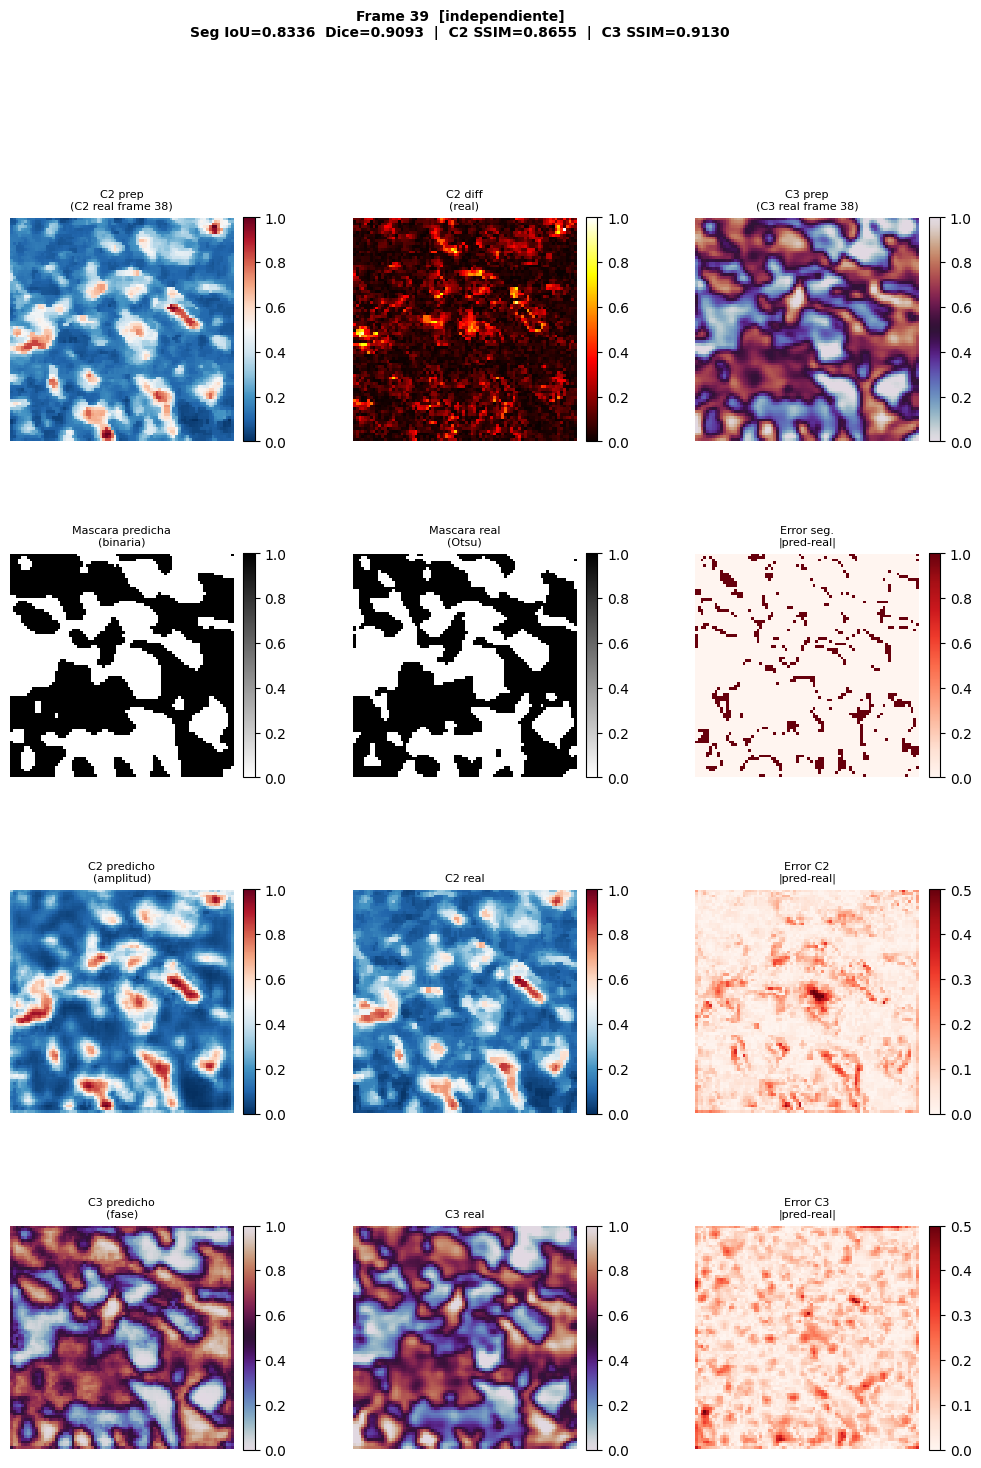

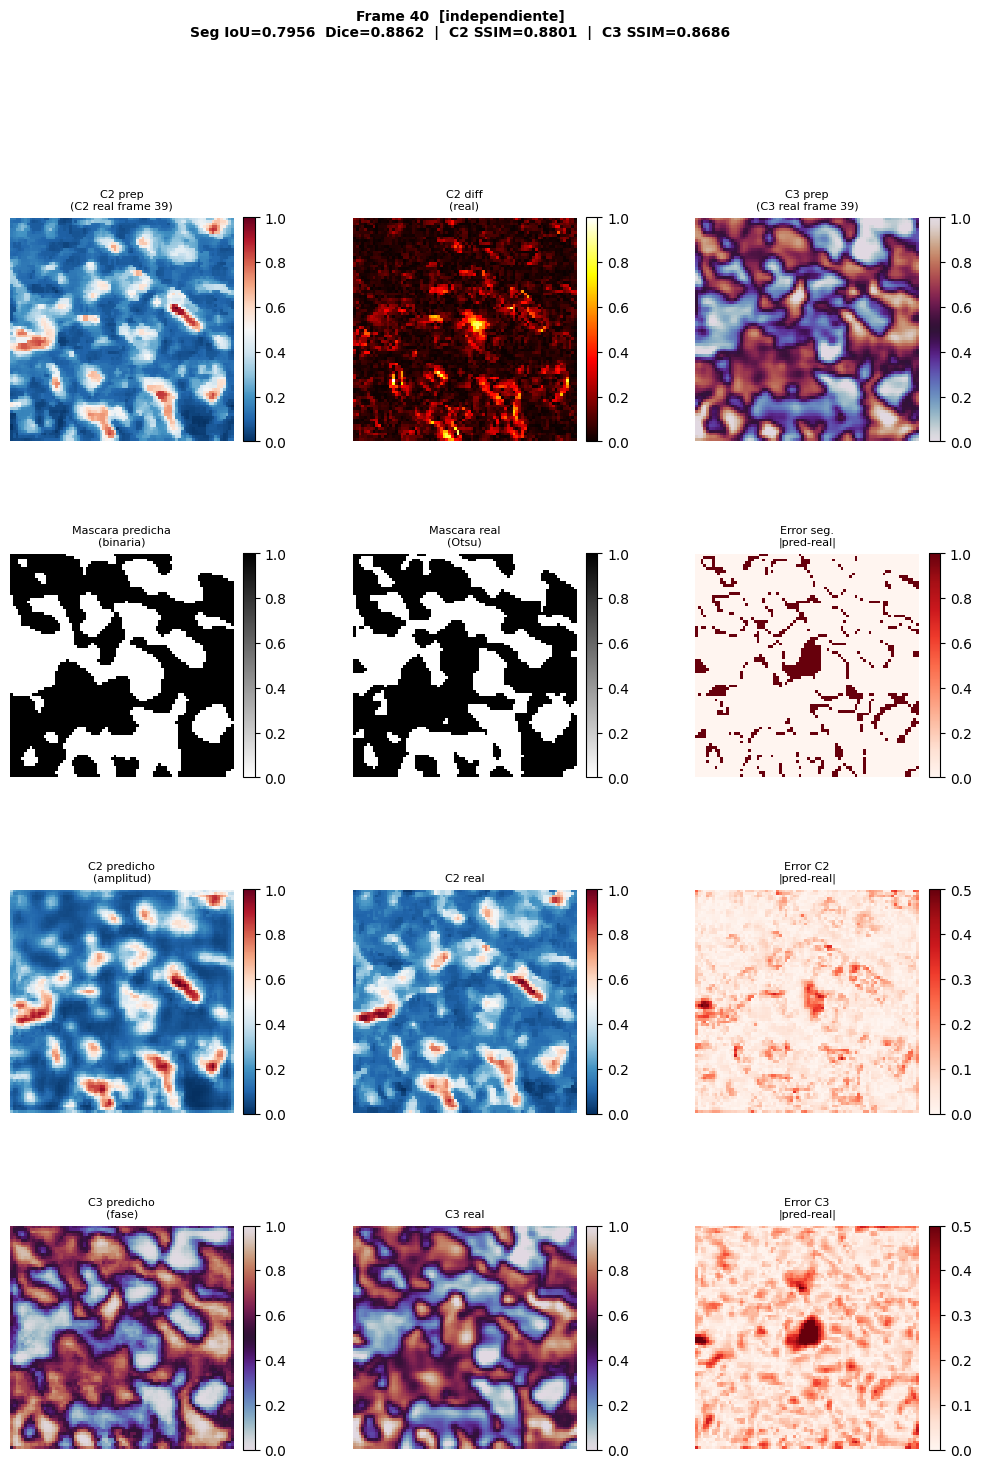


  MODO AUTOREGRESIVA


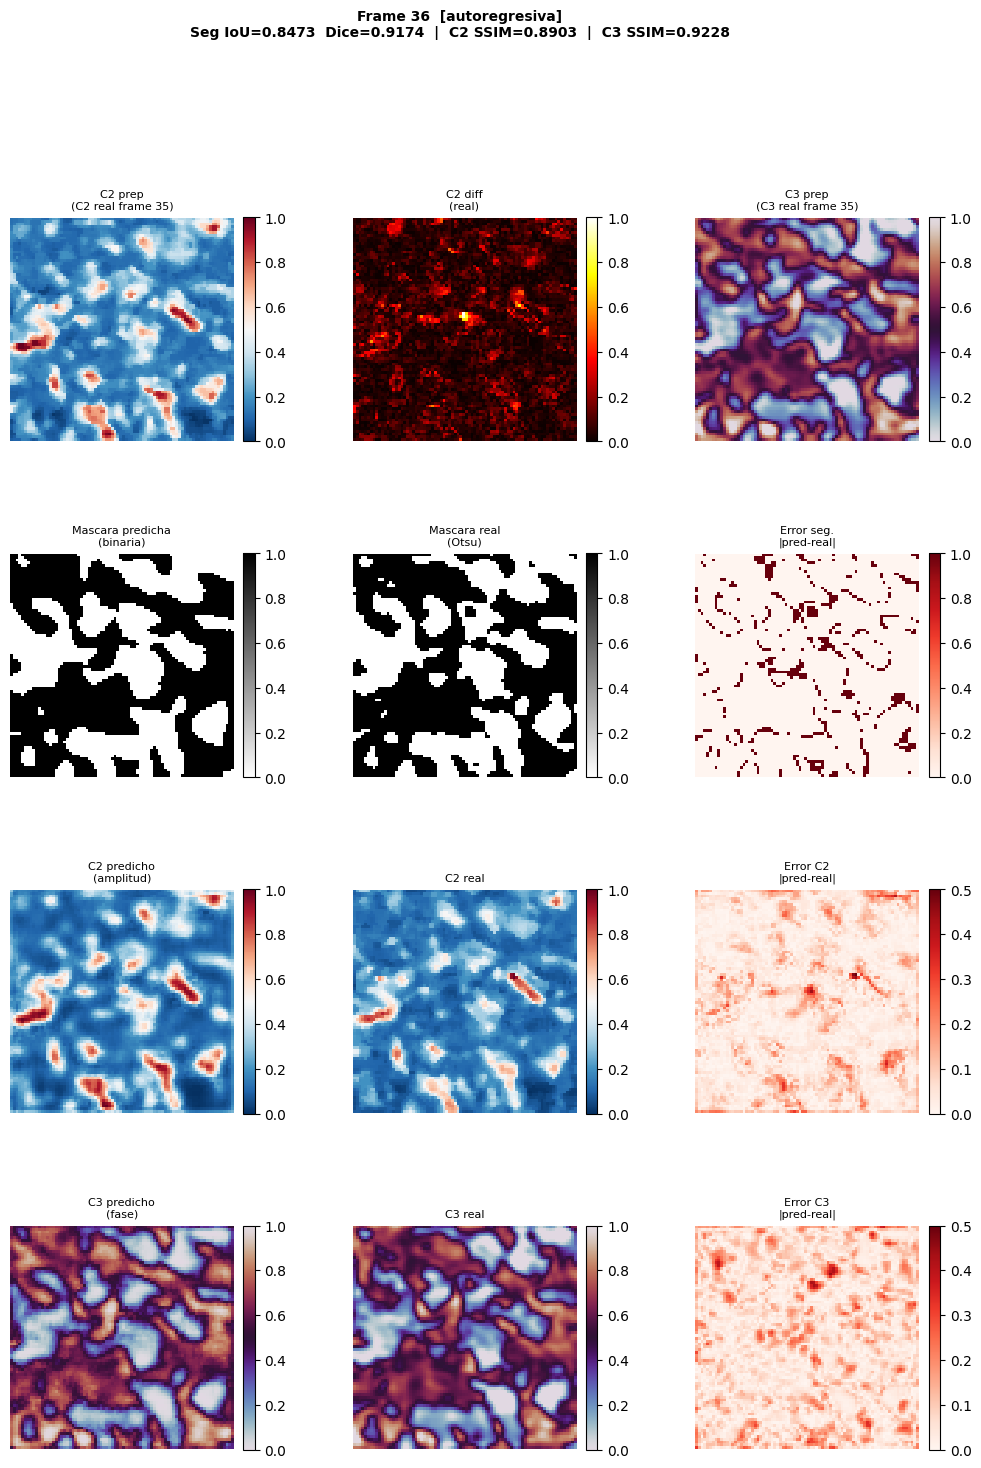

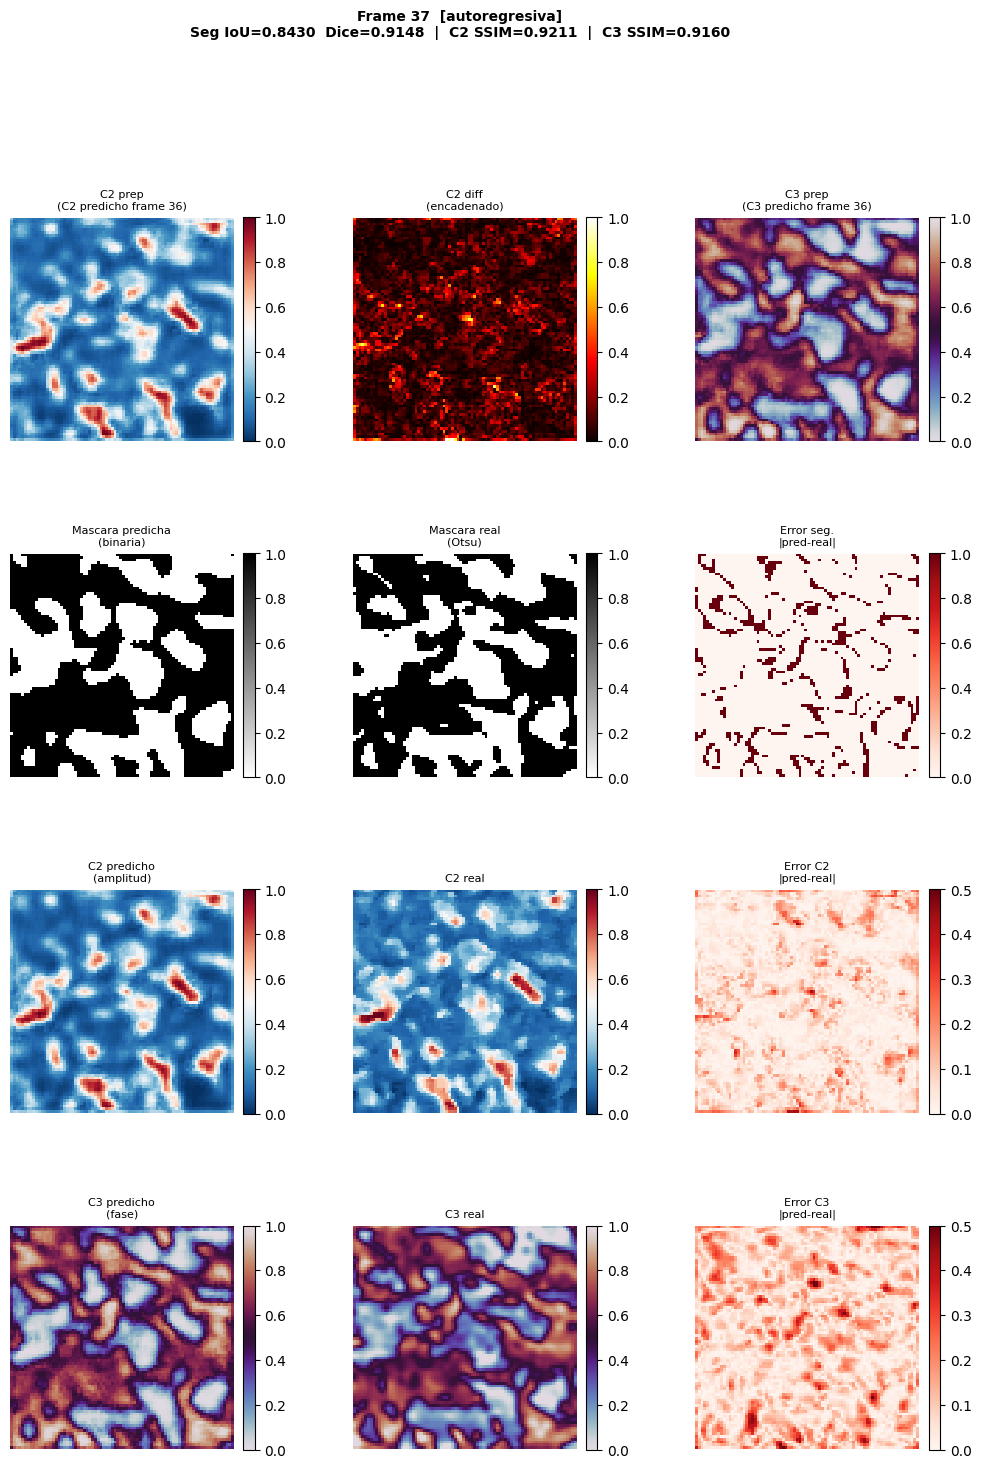

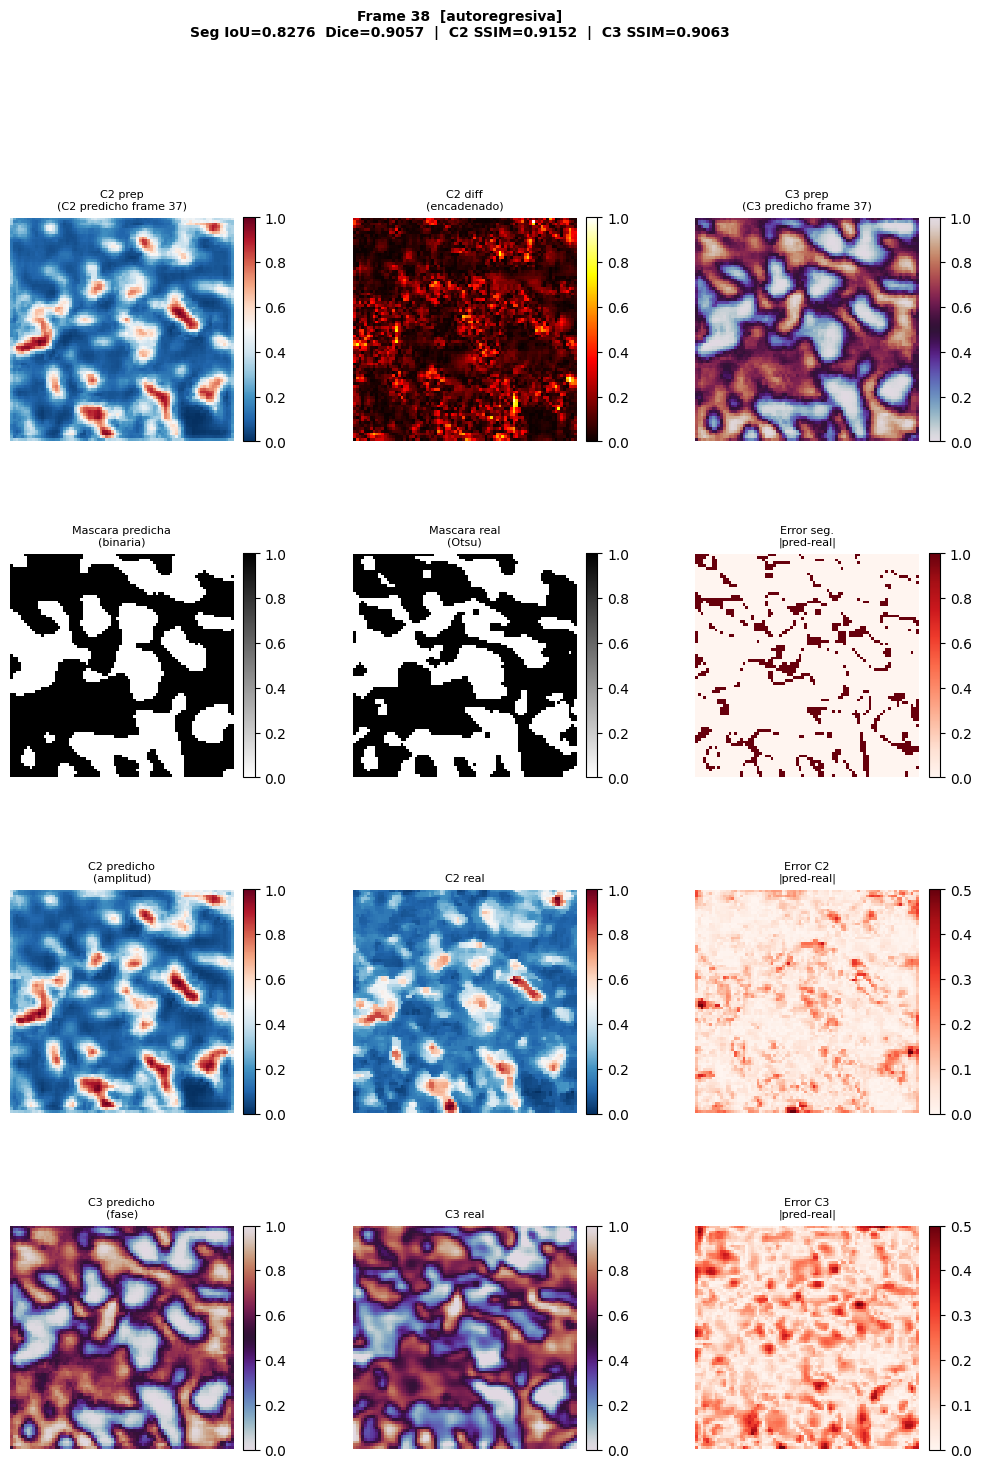

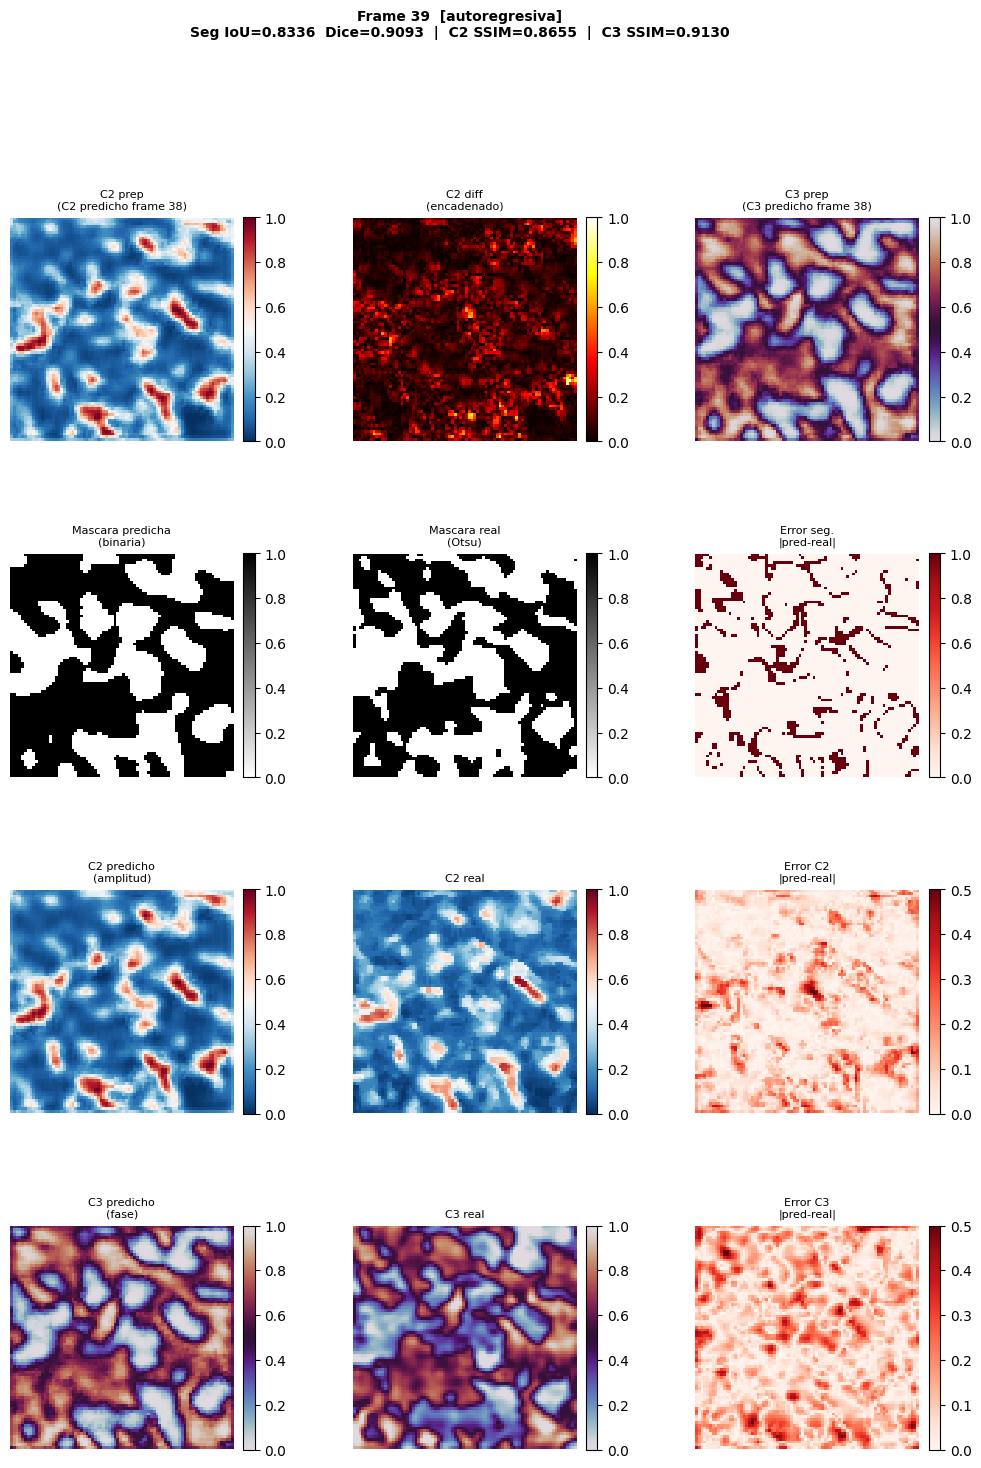

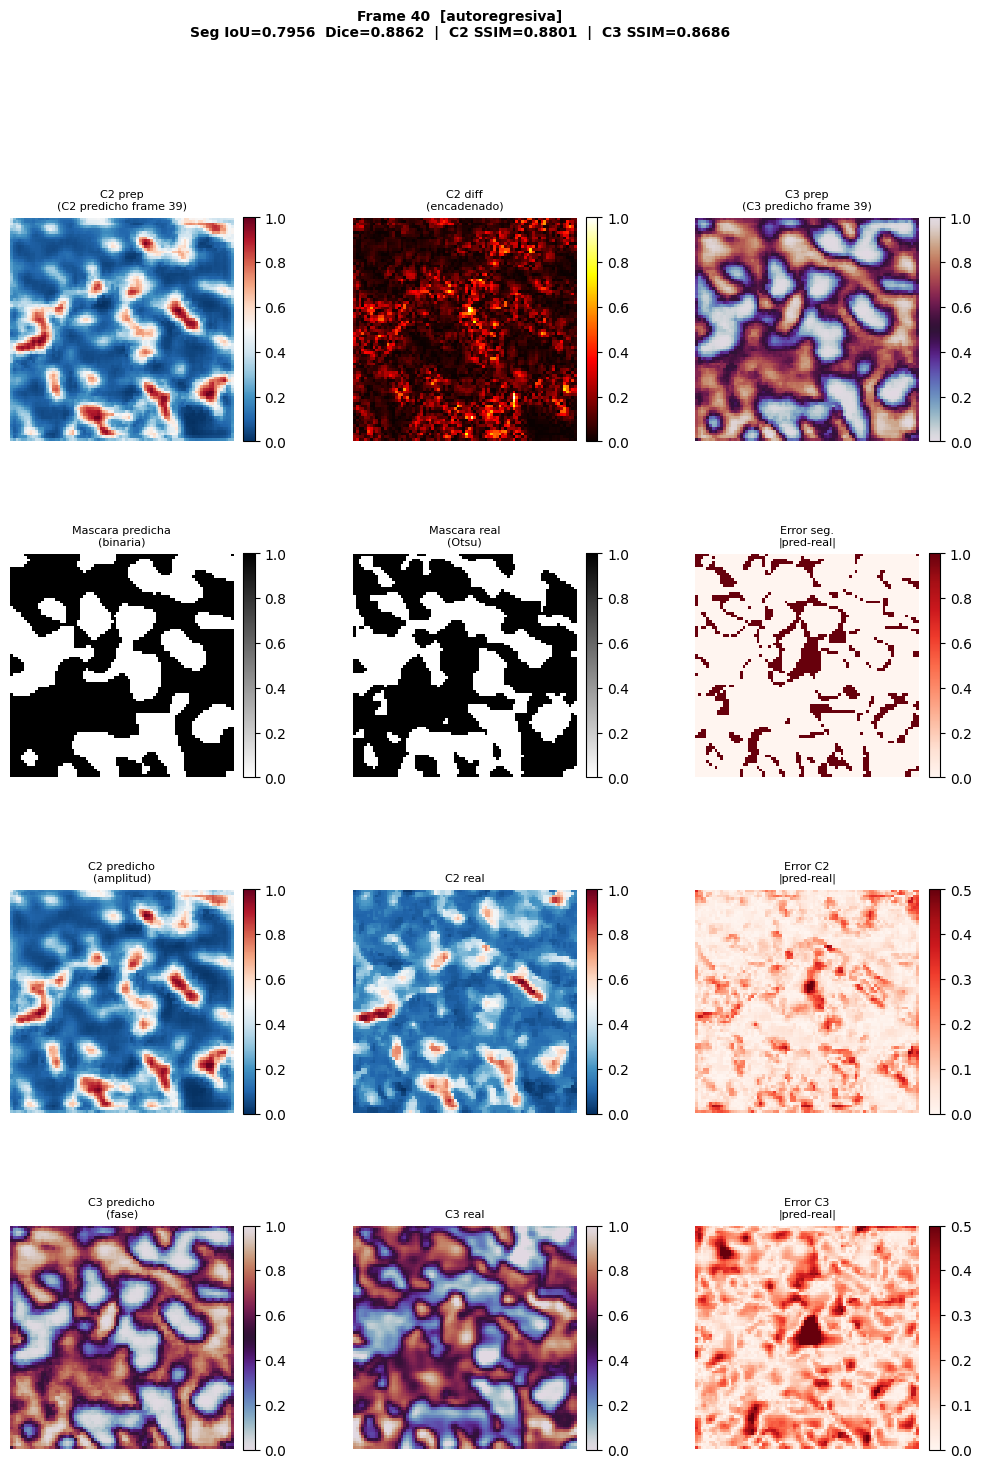


  SIN GROUND TRUTH


ValueError: 'gray_r' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

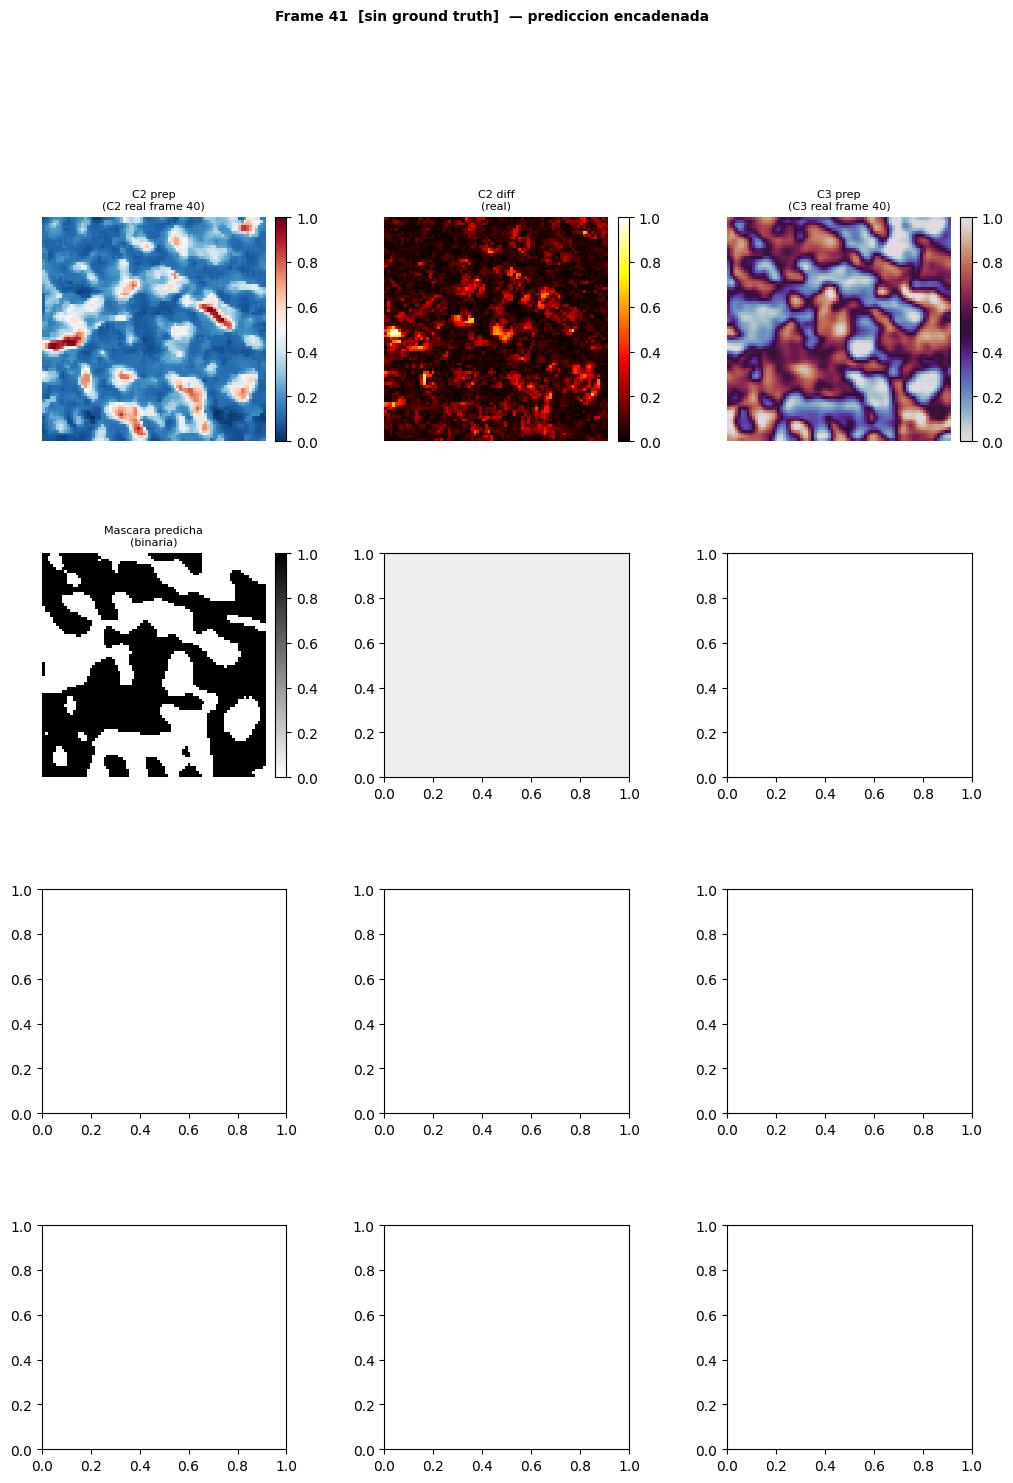

In [22]:
def mostrar_frame(fd):
    fn, has_gt = fd['frame'], fd['has_gt']

    def _m(lst, fn, k):
        for r in lst:
            if int(r.get('pos_out',0)) == fn:
                v = r.get(k)
                return f'{float(v):.4f}' if v not in (None,'','None') else 'N/A'
        return 'N/A'

    if has_gt:
        titulo = (f'Frame {fn}  [{fd["modo"]}]\n'
                  f'Seg IoU={_m(seg_i,fn,"iou")}  Dice={_m(seg_i,fn,"dice")}  |  '
                  f'C2 SSIM={_m(rc2_i,fn,"ssim")}  |  C3 SSIM={_m(rc3_i,fn,"ssim")}')
    else:
        titulo = f'Frame {fn}  [sin ground truth]  — prediccion encadenada'

    c2p, c2d, c3p, c2f, c3f, dff = cargar_inputs_frame(fn, fd['modo'], fd.get('paso', 0))

    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    fig.suptitle(titulo, fontsize=10, fontweight='bold', y=1.01)
    plt.subplots_adjust(hspace=0.5, wspace=0.4)

    for col, (data, title, cmap) in enumerate([
        (c2p, f'C2 prep\n({c2f})',  'RdBu_r'),
        (c2d, f'C2 diff\n({dff})',  'hot'),
        (c3p, f'C3 prep\n({c3f})',  'twilight'),
    ]):
        imshow_cb(axes[0,col], data, cmap, title)
    axes[0,0].set_ylabel(f'Input\nframe {fn-1}', fontsize=8, color=GRAY,
                          fontweight='bold', rotation=90, labelpad=40)

    imshow_cb(axes[1,0], fd['seg_pred'], 'gray_r', 'Mascara predicha\n(binaria)')
    imshow_cb(axes[1,1], fd['seg_real'], 'gray_r',
              'Mascara real\n(Otsu)' if has_gt else f'Mask pred\nframe {fn-1}')
    imshow_cb(axes[1,2], fd['seg_error'], 'Reds',
              'Error seg.\n|pred-real|' if has_gt else f'|mask{fn}-mask{fn-1}|')
    axes[1,0].set_ylabel('Segmentacion', fontsize=8, color=BLUE, fontweight='bold',
                          rotation=90, labelpad=40)

    imshow_cb(axes[2,0], fd['rc2_pred'], 'RdBu_r', 'C2 predicho\n(amplitud)')
    imshow_cb(axes[2,1], fd['rc2_real'], 'RdBu_r',
              'C2 real' if has_gt else f'C2 pred frame {fn-1}')
    imshow_cb(axes[2,2], fd['rc2_error'], 'Reds',
              'Error C2\n|pred-real|' if has_gt else f'|C2_{fn}-C2_{fn-1}|', vmax=0.5)
    axes[2,0].set_ylabel('Regresion C2', fontsize=8, color=PURPLE, fontweight='bold',
                          rotation=90, labelpad=40)

    imshow_cb(axes[3,0], fd['rc3_pred'], 'twilight', 'C3 predicho\n(fase)')
    imshow_cb(axes[3,1], fd['rc3_real'], 'twilight',
              'C3 real' if has_gt else f'C3 pred frame {fn-1}')
    imshow_cb(axes[3,2], fd['rc3_error'], 'Reds',
              'Error C3\n|pred-real|' if has_gt else f'|C3_{fn}-C3_{fn-1}|', vmax=0.5)
    axes[3,0].set_ylabel('Regresion C3', fontsize=8, color=TEAL, fontweight='bold',
                          rotation=90, labelpad=40)

    plt.show(); print()


for _modo, _frames in frames_por_modo.items():
    print("=" * 70)
    print(f"  MODO {_modo.upper()}")
    print("=" * 70)
    for _fd in _frames:
        mostrar_frame(_fd)

if frames_sgt:
    print("=" * 70)
    print("  SIN GROUND TRUTH")
    print("=" * 70)
    for _fd in frames_sgt:
        mostrar_frame(_fd)


## 7. Resúmenes por canal


In [ ]:
def mostrar_resumen(frames_data, etiqueta):
    n = len(frames_data)
    if n == 0: return
    for modelo, cmap, color, label in [
        ('seg', 'gray_r',     BLUE,   'Segmentacion — mascara predicha vs. referencia'),
        ('rc2', 'RdBu_r',   PURPLE, 'Regresion C2 — amplitud PFM predicha vs. referencia'),
        ('rc3', 'twilight', TEAL,   'Regresion C3 — fase PFM predicha vs. referencia'),
    ]:
        fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
        if n == 1: axes = axes.reshape(3,1)
        fig.suptitle(f'{label}  [{etiqueta}]', fontsize=13, fontweight='bold')

        for i, fd in enumerate(frames_data):
            fn = fd['frame']; has_gt = fd['has_gt']
            pred, real, error = (fd.get(f'{modelo}_pred'),
                                 fd.get(f'{modelo}_real'),
                                 fd.get(f'{modelo}_error'))

            if pred is not None: axes[0,i].imshow(pred, cmap=cmap, vmin=0, vmax=1)
            axes[0,i].set_title(f'Pred {fn}', fontsize=8); axes[0,i].axis('off')

            ref_t = f'Real {fn}' if has_gt else f'Pred {fn-1}'
            if real is not None:
                axes[1,i].imshow(real, cmap=cmap, vmin=0, vmax=1)
            else:
                axes[1,i].set_facecolor('#EEEEEE')
                axes[1,i].text(0.5,0.5,'no disp.',ha='center',va='center',
                               fontsize=7,color='gray_r',transform=axes[1,i].transAxes)
            axes[1,i].set_title(ref_t, fontsize=8); axes[1,i].axis('off')

            err_t = f'Error {fn}' if has_gt else f'|{fn}-{fn-1}|'
            if error is not None:
                axes[2,i].imshow(error, cmap='Reds', vmin=0, vmax=0.5)
            else:
                axes[2,i].set_facecolor('#EEEEEE')
                axes[2,i].text(0.5,0.5,'no disp.',ha='center',va='center',
                               fontsize=7,color='gray_r',transform=axes[2,i].transAxes)
            axes[2,i].set_title(err_t, fontsize=8); axes[2,i].axis('off')

        for row, (lab, col) in enumerate([('Prediccion',color),('Referencia',color),('Error',ORANGE)]):
            axes[row,0].set_ylabel(lab, fontsize=9, fontweight='bold', color=col)

        plt.tight_layout(); plt.show()


for _modo, _frames in frames_por_modo.items():
    mostrar_resumen(_frames, _modo)
if frames_sgt:
    mostrar_resumen(frames_sgt, 'sin ground truth')


## 8. Análisis de error y degradación autoregresiva


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis de error — distribución y degradación autoregresiva',
             fontsize=13, fontweight='bold', y=0.98)

def fs(lst): return [int(r['pos_out']) for r in lst]
def vs(lst, k): return [r.get(k) for r in lst]

# Fila 0 — Barras por frame
for ax, lst, key, color, title, ylabel in [
    (axes[0,0], seg_i, 'iou',  BLUE,   'Segmentación — IoU por frame',  'IoU'),
    (axes[0,1], rc2_i, 'mse',  PURPLE, 'Regresión C2 — MSE por frame',  'MSE'),
    (axes[0,2], rc3_i, 'mse',  TEAL,   'Regresión C3 — MSE por frame',  'MSE'),
]:
    if lst:
        axes_x = fs(lst); axes_y = vs(lst, key)
        ax.bar(axes_x, axes_y, color=color, alpha=0.8, width=0.6)
        ax.set_xticks(axes_x)
        ax.set_title(title, fontsize=9); ax.set_xlabel('frame predicho', fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Fila 1 — Degradación autoregresiva
for ax, li, la, key, color, title, ylabel in [
    (axes[1,0], seg_i, seg_a, 'iou',  BLUE,   'Segmentación — degradación auto.', 'IoU'),
    (axes[1,1], rc2_i, rc2_a, 'ssim', PURPLE, 'Regresión C2 — degradación auto.', 'SSIM'),
    (axes[1,2], rc3_i, rc3_a, 'ssim', TEAL,   'Regresión C3 — degradación auto.', 'SSIM'),
]:
    if li and la:
        xi = fs(li); yi = vs(li,key)
        xa = fs(la); ya = vs(la,key)
        ax.plot(xi, yi, 'o-',  color=color,  lw=2, ms=7, label='independiente')
        ax.plot(xa, ya, 's--', color=ORANGE, lw=2, ms=7, label='autoregresiva')
        ax.fill_between(xi, ya[:len(xi)], yi, alpha=0.15, color=color)
        ax.set_ylim(0.7, 1.0); ax.set_xticks(xi)
        ax.set_title(title, fontsize=9); ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Tabla de viabilidad


In [ ]:
caida = lambda vi, va, k: (
    f"{abs((avg(va,k) or 0)-(avg(vi,k) or 0))*100:.1f}%" 
    if avg(vi,k) is not None and avg(va,k) is not None else 'N/A'
)
def ep(ckpt, key, fmt='.4f'):
    v = ckpt.get(key)
    return f'{float(v):{fmt}}' if isinstance(v,(int,float)) else 'N/A'

print("=" * 70)
print(f"{'MÉTRICA':<25} {'SEG indep':>10} {'SEG auto':>10} {'C2 indep':>10} {'C2 auto':>10} {'C3 indep':>10} {'C3 auto':>10}")
print("-" * 70)
rows = [
    ('IoU promedio',         avg_str(seg_i,'iou'),  avg_str(seg_a,'iou'),  '-','-','-','-'),
    ('Dice promedio',        avg_str(seg_i,'dice'), avg_str(seg_a,'dice'), '-','-','-','-'),
    ('SSIM promedio',        '-','-',  avg_str(rc2_i,'ssim'), avg_str(rc2_a,'ssim'), avg_str(rc3_i,'ssim'), avg_str(rc3_a,'ssim')),
    ('PSNR promedio (dB)',   '-','-',  avg_str(rc2_i,'psnr','.2f'), avg_str(rc2_a,'psnr','.2f'), avg_str(rc3_i,'psnr','.2f'), avg_str(rc3_a,'psnr','.2f')),
    ('Mejor epoch (train)',  str(int(seg_ckpt.get('epoch',0))) if seg_ckpt.get('epoch') else 'N/A', '-', str(int(rc2_ckpt.get('epoch',0))) if rc2_ckpt.get('epoch') else 'N/A', '-', str(int(rc3_ckpt.get('epoch',0))) if rc3_ckpt.get('epoch') else 'N/A', '-'),
    ('Val IoU/SSIM (train)', ep(seg_ckpt,'val_iou'),'-', ep(rc2_ckpt,'val_ssim'),'-', ep(rc3_ckpt,'val_ssim'),'-'),
    ('Caída autoregresiva',  caida(seg_i,seg_a,'iou'),'-', caida(rc2_i,rc2_a,'ssim'),'-', caida(rc3_i,rc3_a,'ssim'),'-'),
]
for r in rows:
    print(f"{r[0]:<25} {r[1]:>10} {r[2]:>10} {r[3]:>10} {r[4]:>10} {r[5]:>10} {r[6]:>10}")
print("=" * 70)